In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 5000

temperature = np.random.normal(60, 10, n)
voltage = np.random.normal(1.2, 0.1, n)
access_frequency = np.random.randint(1000, 100000, n)
refresh_rate = np.random.randint(32, 128, n)
retention_time = np.random.randint(50, 500, n)

fault = (
    (temperature > 75) |
    (voltage < 1.05) |
    (retention_time < 100) |
    (access_frequency > 80000)
).astype(int)

df = pd.DataFrame({
    'temperature': temperature,
    'voltage': voltage,
    'access_frequency': access_frequency,
    'refresh_rate': refresh_rate,
    'retention_time': retention_time,
    'fault': fault
})

df.head()

,temperature,voltage,access_frequency,refresh_rate,retention_time,fault
0,64.967142,1.157624,23135,69,82,1
1,58.617357,1.154659,97080,85,352,1
2,66.476885,1.020436,38918,91,293,1
3,75.230299,1.166991,51849,108,221,1
4,57.658466,1.273283,31847,108,256,0


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("fault", axis=1)
y = df["fault"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [5]:
y_pred = model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       608
           1       0.99      1.00      1.00       392

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [8]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[606   2]
 [  0 392]]


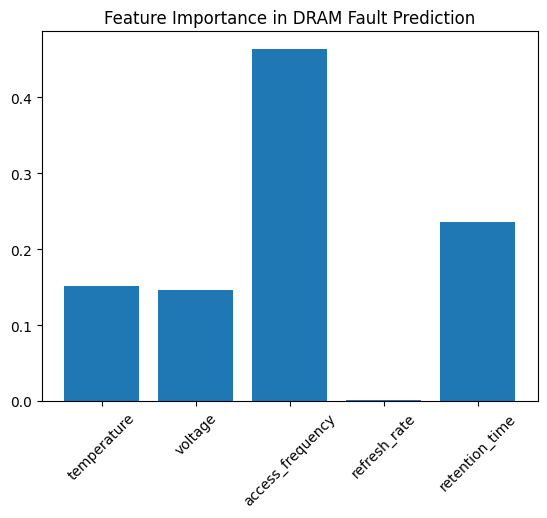

In [9]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance in DRAM Fault Prediction")
plt.show()

In [11]:
sample = pd.DataFrame([[80, 1.0, 90000, 40, 70]],
                      columns=X.columns)

prediction = model.predict(sample)
prob = model.predict_proba(sample)

print("Prediction:", prediction)
print("Fault Probability:", prob)

Prediction: [1]
Fault Probability: [[0. 1.]]
